# 1. Importing Required Libraries

In [1]:
# Import NumPy for array handling and numerical computations
import numpy as np
# Import Matplotlib for creating various plots and visualizations
import matplotlib.pyplot as plt
# Import the normal distribution class from SciPy for statistical calculations
from scipy.stats import norm
#Import these for last section called extra
from math import erf, sqrt, log, pi

# 2. Configuring Plot Settings

In [2]:
# Set the default figure size for all plots
plt.rcParams['figure.figsize'] = (8, 6)
# Set the default font size used in plot elements
plt.rcParams['font.size'] = 12

# 3. Defining Class Distributions and Priors

In [3]:
# Define mean and standard deviation for Class 1
mu1, sigma1 = 0, 1    
# Define mean and standard deviation for Class 2
mu2, sigma2 = 1, 1    
# Generate a range of x values for evaluating the PDFs
x = np.linspace(-3, 4, 2000)
# Compute the probability density function for Class 1
px_c1 = norm.pdf(x, mu1, sigma1)
# Compute the probability density function for Class 2
px_c2 = norm.pdf(x, mu2, sigma2)
# Set prior probability for Class 1
P1 = 2/3
# Set prior probability for Class 2
P2 = 1/3

# 4. Computing and Plotting the MAP Decision Boundary

MAP decision boundary (0-1 loss) at x = 1.1916


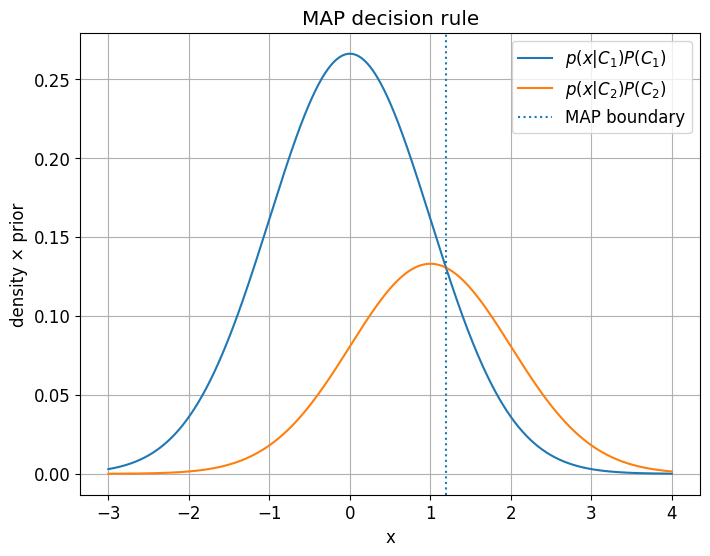

In [4]:
# Compute unnormalized posterior for Class 1
post1_unnorm = px_c1 * P1
# Compute unnormalized posterior for Class 2
post2_unnorm = px_c2 * P2
# Locate the index where the two unnormalized posteriors intersect
idx_db_map = np.argwhere(np.diff(np.sign(post1_unnorm - post2_unnorm))).flatten()
# Extract the corresponding x-value as the MAP decision boundary
x_db_map = x[idx_db_map][0]
# Display the calculated MAP decision boundary
print(f"MAP decision boundary (0-1 loss) at x = {x_db_map:.4f}")
# Plot the unnormalized posterior for Class 1
plt.plot(x, post1_unnorm, label=r"$p(x|C_1)P(C_1)$")
# Plot the unnormalized posterior for Class 2
plt.plot(x, post2_unnorm, label=r"$p(x|C_2)P(C_2)$")
# Mark the MAP decision boundary with a vertical dashed line
plt.axvline(x_db_map, linestyle=':', label='MAP boundary')
# Label the x-axis
plt.xlabel("x")
# Label the y-axis
plt.ylabel("density × prior")
# Add legend to distinguish curves
plt.legend()
# Enable grid for better readability
plt.grid(True)
# Add a title to the plot
plt.title("MAP decision rule")
# Display the final plot
plt.show()

# 5. Computing FNR and FAR and Visualizing Their Behavior

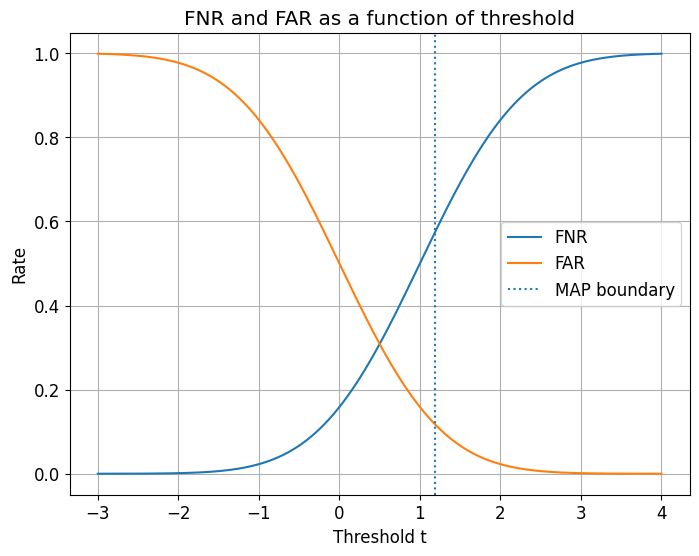

In [5]:
# Use the same x-range as the set of threshold values
t = x
# Compute the False Negative Rate for Class 1 using the survival function
FAR = norm.sf(t, mu1, sigma1)
# Compute the False Alarm Rate for Class 2 using the survival function
FNR = norm.cdf(t, mu2, sigma2)
# Plot the False Negative Rate curve
plt.plot(t, FNR, label="FNR")
# Plot the False Alarm Rate curve
plt.plot(t, FAR, label="FAR")
# Draw the MAP boundary as a vertical dashed line
plt.axvline(x_db_map, linestyle=':', label="MAP boundary")
# Label the x-axis with threshold notation
plt.xlabel("Threshold t")
# Label the y-axis to represent rate values
plt.ylabel("Rate")
# Add a title describing the plot
plt.title("FNR and FAR as a function of threshold")
# Show a legend to distinguish plotted curves
plt.legend()
# Enable grid for readability
plt.grid(True)
# Display the plot
plt.show()

# 6. Computing the Equal Error Rate (EER) and Plotting the Result

EER ≈ 0.3079 at threshold t ≈ 0.4982


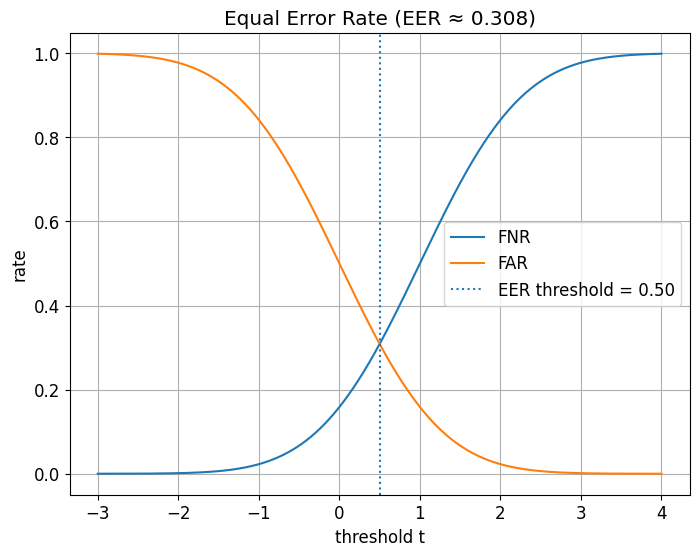

In [6]:
# Compute the absolute difference between FNR and FAR
diff = np.abs(FNR - FAR)
# Find the index where the difference is minimal (closest to equal)
idx_eer = np.argmin(diff)
# Extract the corresponding threshold value as the EER threshold
t_eer = t[idx_eer]
# Extract the Equal Error Rate value
EER = FNR[idx_eer]
# Print the computed EER with its threshold
print(f"EER ≈ {EER:.4f} at threshold t ≈ {t_eer:.4f}")
# Plot the False Negative Rate curve
plt.plot(t, FNR, label="FNR")
# Plot the False Alarm Rate curve
plt.plot(t, FAR, label="FAR")
# Mark the EER threshold with a vertical dashed line
plt.axvline(t_eer, linestyle=':', label=f"EER threshold = {t_eer:.2f}")
# Label the x-axis as threshold
plt.xlabel("threshold t")
# Label the y-axis as rate
plt.ylabel("rate")
# Add a title showing the EER value
plt.title(f"Equal Error Rate (EER ≈ {EER:.3f})")
# Add a legend to distinguish elements
plt.legend()
# Enable grid lines for clarity
plt.grid(True)
# Display the plot
plt.show()

# 7. Computing the ROC Curve

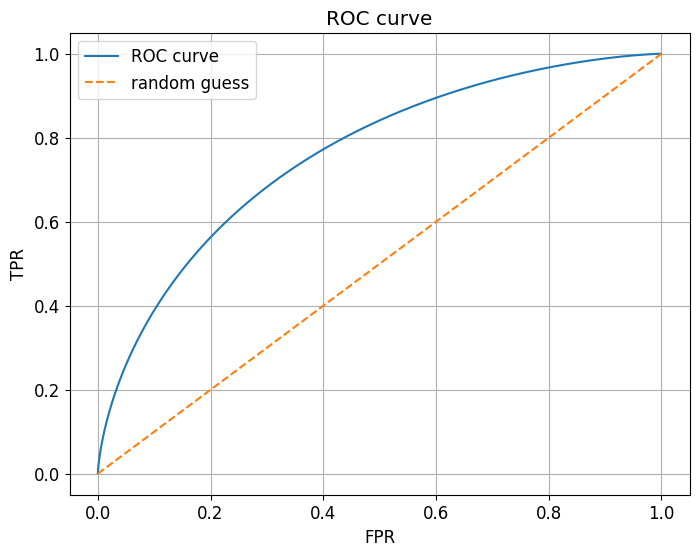

In [ ]:
# Compute the True Positive Rate using TPR = 1 - FNR
TPR = 1 - FNR  
# The False Positive Rate is equal to FAR in this context
FPR = FAR      
# Plot the ROC curve using FPR on the x-axis and TPR on the y-axis
plt.plot(FPR, TPR, label="ROC curve")
# Plot the diagonal line representing random guessing
plt.plot([0, 1], [0, 1], '--', label="random guess")
# Label the x-axis as False Positive Rate
plt.xlabel("FPR")
# Label the y-axis as True Positive Rate
plt.ylabel("TPR")
# Add a title for the ROC plot
plt.title("ROC curve")
# Display the legend to distinguish curves
plt.legend()
# Enable grid lines for visual clarity
plt.grid(True)
# Show the final ROC plot
plt.show()

# 8. Defining the Loss Matrix

In [8]:
# Define the loss matrix for a two-class classification problem
Lambda = np.array([[0, 2], [1, 0]])
# Extract the loss of deciding C2 when the true class is C1
lambda_12 = Lambda[0, 1]
# Extract the loss of deciding C1 when the true class is C2
lambda_21 = Lambda[1, 0]

# 9. Bayes Optimal Boundary and Risk vs. Class Prior

In this section, I sweep over different prior probabilities for class C1, compute the corresponding Bayes-optimal decision boundary and its associated Bayes risk, and then visualize how the optimal threshold changes as a function of 𝑃(𝐶_1)


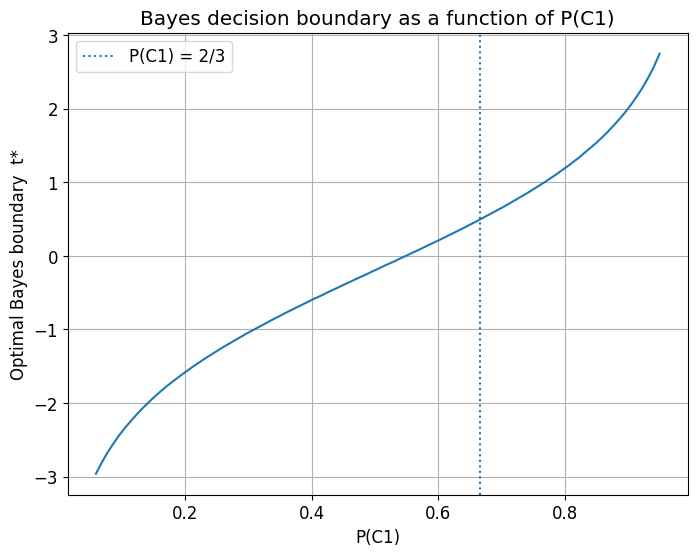

In [9]:
# Generate a range of prior probabilities for Class 1
P1_vals = np.linspace(0.05, 0.95, 100)
# Compute the corresponding prior probabilities for Class 2
P2_vals = 1 - P1_vals
# Initialize a list to store the optimal decision boundary for each prior
db_opt = []         
# Initialize a list to store the minimal Bayes risk for each prior
risk_opt = []       
# Loop over all prior probability pairs (P(C1), P(C2))
for P1_i, P2_i in zip(P1_vals, P2_vals):
    # Compute conditional risk of deciding C1 at each x
    R_dec1 = lambda_12 * P2_i * px_c2     
    # Compute conditional risk of deciding C2 at each x
    R_dec2 = lambda_21 * P1_i * px_c1     
    # Find indices where the two risk curves intersect
    idx_db = np.argwhere(np.diff(np.sign(R_dec1 - R_dec2))).flatten()
    # If no intersection exists, store NaN and continue to the next prior
    if len(idx_db) == 0:
        db_opt.append(np.nan)
        risk_opt.append(np.nan)
        continue
    # Extract the optimal decision boundary t* from the first intersection
    t_star = x[idx_db][0]
    db_opt.append(t_star)
    # Compute miss probability for C1 (false negative) at t*
    alpha = norm.sf(t_star, mu1, sigma1)     
    # Compute miss probability for C2 (false positive) at t*
    beta  = norm.cdf(t_star, mu2, sigma2)    
    # Compute the Bayes risk for this choice of priors and threshold
    R = lambda_12 * alpha * P1_i + lambda_21 * beta * P2_i
    risk_opt.append(R)
# Convert lists to NumPy arrays for easier handling
db_opt  = np.array(db_opt)
risk_opt = np.array(risk_opt)
# Plot the optimal Bayes decision boundary as a function of P(C1)
plt.plot(P1_vals, db_opt)
# Highlight the original prior P(C1) = 2/3 used earlier
plt.axvline(P1, linestyle=':', label="P(C1) = 2/3")
# Label the x-axis with the prior of Class 1
plt.xlabel("P(C1)")
# Label the y-axis with the optimal decision threshold
plt.ylabel("Optimal Bayes boundary  t*")
# Add a title describing the relationship being plotted
plt.title("Bayes decision boundary as a function of P(C1)")
# Enable grid lines for clarity
plt.grid(True)
# Show the legend to identify the reference prior line
plt.legend()
# Display the plot
plt.show()

# 10. Plotting the Optimal Bayes Risk

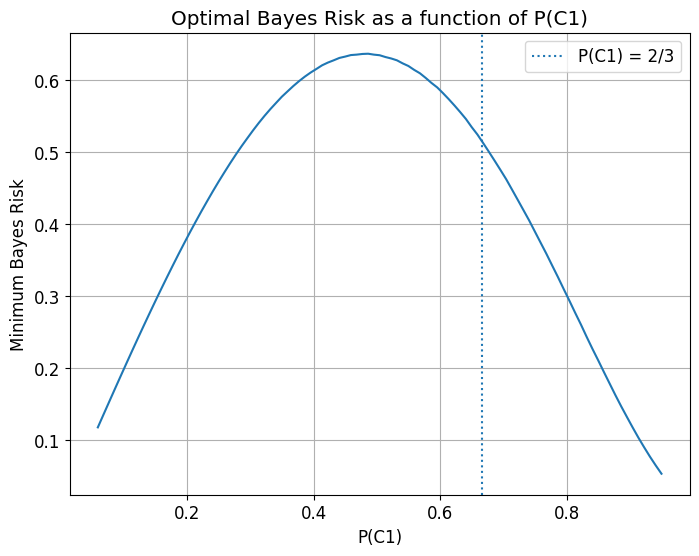

In [10]:
# Plot the optimal Bayes risk computed for each value of P(C1)
plt.plot(P1_vals, risk_opt)
# Highlight the original prior P(C1) = 2/3 for reference
plt.axvline(P1, linestyle=':', label="P(C1) = 2/3")
# Label the x-axis with the prior for Class 1
plt.xlabel("P(C1)")
# Label the y-axis with the minimum Bayes risk
plt.ylabel("Minimum Bayes Risk")
# Add a descriptive title to the plot
plt.title("Optimal Bayes Risk as a function of P(C1)")
# Enable grid lines to improve readability
plt.grid(True)
# Display legend to identify reference markers
plt.legend()
# Show the final plot
plt.show()

# 11. Evaluating Risk with a Fixed Decision Boundary

In this section, we freeze the Bayes-optimal boundary computed for the original prior 𝑃(𝐶_1)=2/3, keep that threshold fixed, and evaluate how the resulting risk changes when the class priors vary.

Bayes boundary for P(C1)=2/3 : t* = 0.4982


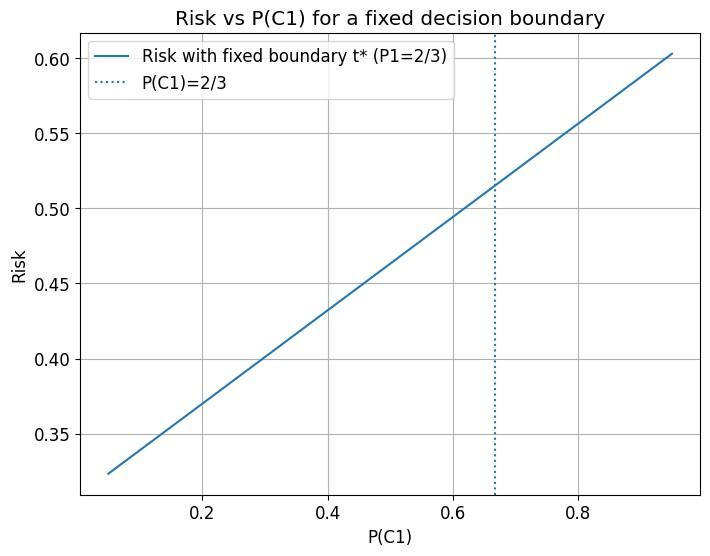

In [11]:
# Compute the conditional risks using the original priors P1=2/3 and P2=1/3
R_dec1_fixed = lambda_12 * P2 * px_c2
R_dec2_fixed = lambda_21 * P1 * px_c1
# Find the decision boundary corresponding to the original priors
idx_db_fixed = np.argwhere(np.diff(np.sign(R_dec1_fixed - R_dec2_fixed))).flatten()
t_fixed = x[idx_db_fixed][0]
# Print the Bayes-optimal boundary for P(C1)=2/3
print(f"Bayes boundary for P(C1)=2/3 : t* = {t_fixed:.4f}")
# Initialize a list to store the risk obtained when the boundary is kept fixed
risk_fixed_boundary = []
# Evaluate the risk for each pair of varying priors (P1_i, P2_i)
for P1_i, P2_i in zip(P1_vals, P2_vals):
    # False negative probability at the fixed boundary
    alpha = norm.sf(t_fixed, mu1, sigma1)    
    # False positive probability at the fixed boundary
    beta  = norm.cdf(t_fixed, mu2, sigma2)  
    # Compute the risk using the fixed threshold t_fixed
    R = lambda_12 * alpha * P1_i + lambda_21 * beta * P2_i
    risk_fixed_boundary.append(R)
# Convert the list of risks to a NumPy array
risk_fixed_boundary = np.array(risk_fixed_boundary)
# Plot the risk obtained by keeping the decision boundary fixed
plt.plot(P1_vals, risk_fixed_boundary, label="Risk with fixed boundary t* (P1=2/3)")
# Mark the original prior probability P(C1)=2/3
plt.axvline(P1, linestyle=':', label="P(C1)=2/3")
# Label the x-axis (prior for Class 1)
plt.xlabel("P(C1)")
# Label the y-axis (resulting risk)
plt.ylabel("Risk")
# Add a descriptive title
plt.title("Risk vs P(C1) for a fixed decision boundary")
# Enable grid lines for clarity
plt.grid(True)
# Show the legend for curve identification
plt.legend()
# Display the final plot
plt.show()

# 12. Evaluating the Prior-Independent (Robust) Threshold

Threshold independent of priors (probability-of-error sense) ≈ 0.4982


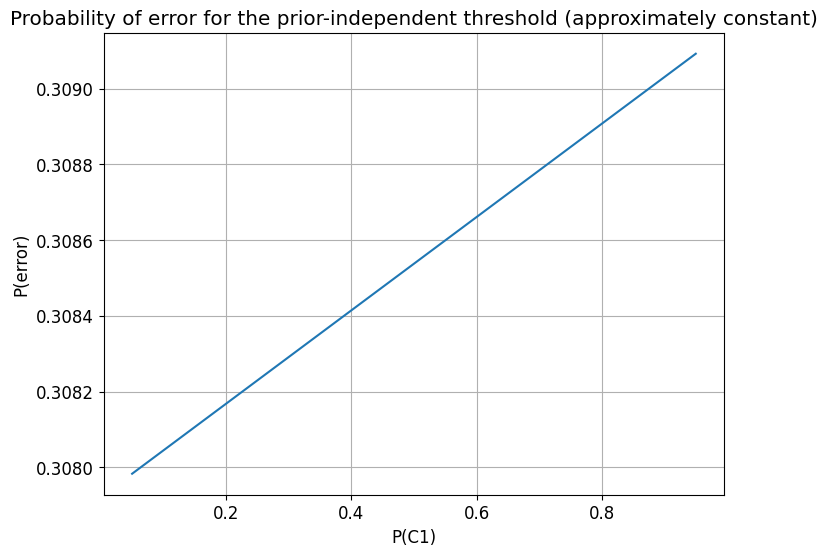

In [12]:
# Use the EER threshold as a prior-independent (robust) threshold
t_robust = t_eer
# Print the robust threshold value
print(f"Threshold independent of priors (probability-of-error sense) ≈ {t_robust:.4f}")
# Initialize a list to store the probability of error for each prior
Pe_vals = []
# Compute probability of error for each value of P(C1) and P(C2)
for P1_i, P2_i in zip(P1_vals, P2_vals):
    # False negative probability at the robust threshold
    alpha = norm.sf(t_robust, mu1, sigma1)  
    # False positive probability at the robust threshold
    beta  = norm.cdf(t_robust, mu2, sigma2)  
    # Compute total probability of error
    Pe = alpha * P1_i + beta * P2_i         
    Pe_vals.append(Pe)
# Convert list to NumPy array
Pe_vals = np.array(Pe_vals)
# Plot the probability of error for different priors using the robust threshold
plt.plot(P1_vals, Pe_vals)
# Label the x-axis as the prior of Class 1
plt.xlabel("P(C1)")
# Label the y-axis as the probability of error
plt.ylabel("P(error)")
# Add a descriptive title
plt.title("Probability of error for the prior-independent threshold (approximately constant)")
# Enable grid for visual clarity
plt.grid(True)
# Display the plot
plt.show()

# 13. EXtra
### Extra 1 – Visualizing class PDFs and decision thresholds

In this cell I plot the two class-conditional Gaussian PDFs, compute three different decision thresholds (MAP, minimum-risk with a cost matrix, and the simple mid-point), and highlight the regions that correspond to false alarms and missed detections for the MAP threshold. 


MAP threshold: -0.1931471805599453
Min-Risk threshold: 0.5
Mid-point threshold: 0.5


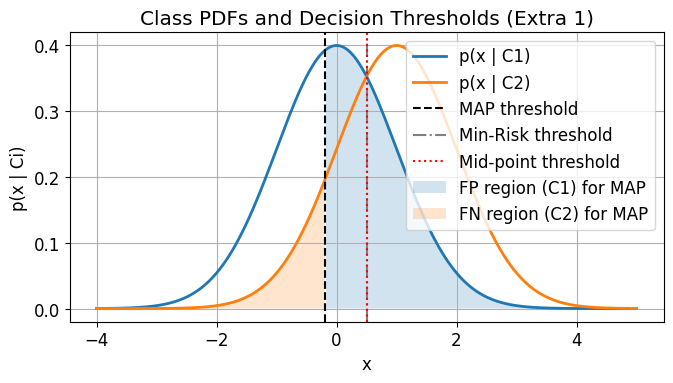

In [13]:
mu1, mu2 = 0.0, 1.0
sigma1 = sigma2 = 1.0
p1, p2 = 2/3, 1/3
L10, L01 = 2.0 , 1.0 
# Grid of x values where I evaluate the PDFs
x = np.linspace(mu1 - 4 * sigma1, mu2 + 4 * sigma2, 500)
# Class-conditional Gaussian PDFs p(x | C1) and p(x | C2)
pdf1 = (1.0 / (sqrt(2 * pi) * sigma1)) * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
pdf2 = (1.0 / (sqrt(2 * pi) * sigma2)) * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
# MAP decision threshold (equal misclassification cost)
th_map = 0.5 * (mu1 + mu2) + (sigma1 ** 2 / (mu2 - mu1)) * np.log(p2 / p1)
# Asymmetric cost matrix from the problem statement
# L10: deciding C1 when C2 is actually true
# L01: deciding C2 when C1 is actually true
L10 = 2.0
L01 = 1.0
# Minimum-risk threshold under the given cost matrix
th_min_risk = 0.5 * (mu1 + mu2) + (sigma1 ** 2 / (mu2 - mu1)) * np.log((p2 * L10) / (p1 * L01))
# Simple prior-independent threshold: just the mid-point of the means
th_mid = 0.5 * (mu1 + mu2)
print("MAP threshold:", th_map)
print("Min-Risk threshold:", th_min_risk)
print("Mid-point threshold:", th_mid)
plt.figure(figsize=(7, 4))
# Plot both class PDFs
plt.plot(x, pdf1, label="p(x | C1)", linewidth=2)
plt.plot(x, pdf2, label="p(x | C2)", linewidth=2)
# Vertical lines for the three thresholds
plt.axvline(th_map, color="k", linestyle="--", label="MAP threshold")
plt.axvline(th_min_risk, color="gray", linestyle="-.", label="Min-Risk threshold")
plt.axvline(th_mid, color="r", linestyle=":", label="Mid-point threshold")
# Region of false alarms (FP) for the MAP threshold: decide C2 while C1 is true
x_fp = x[x > th_map]
pdf1_fp = (1.0 / (sqrt(2 * pi) * sigma1)) * np.exp(-0.5 * ((x_fp - mu1) / sigma1) ** 2)
plt.fill_between(x_fp, pdf1_fp, 0, alpha=0.2, label="FP region (C1) for MAP")
# Region of missed detections (FN) for the MAP threshold: decide C1 while C2 is true
x_fn = x[x <= th_map]
pdf2_fn = (1.0 / (sqrt(2 * pi) * sigma2)) * np.exp(-0.5 * ((x_fn - mu2) / sigma2) ** 2)
plt.fill_between(x_fn, pdf2_fn, 0, alpha=0.2, label="FN region (C2) for MAP")
plt.title("Class PDFs and Decision Thresholds (Extra 1)")
plt.xlabel("x")
plt.ylabel("p(x | Ci)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra 2 – Monte Carlo ROC curve and EER

Here I generate a large set of samples from both classes using the given Gaussian models and priors. For a sweep of decision thresholds, I compute the confusion statistics, build the ROC curve (TPR vs FPR), and approximate the Equal Error Rate (EER) by finding where FPR and FNR are closest.


EER threshold (approx): 0.5150501672240804
EER value (approx): 0.31026545207738065


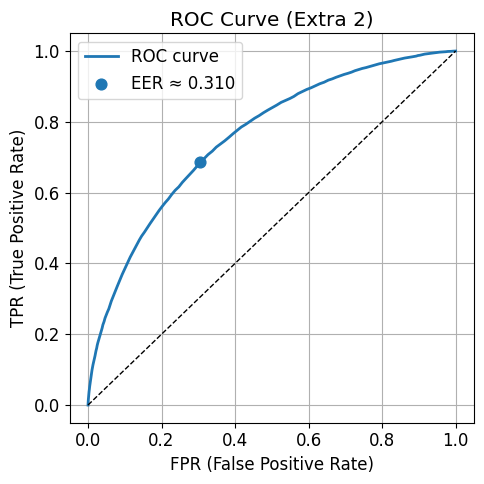

In [14]:
# I simulate labeled samples according to the class priors and Gaussian models
N = 50000
labels = np.random.choice([0, 1], size=N, p=[p1, p2])  # 0 = C1, 1 = C2
samples = np.zeros(N)
# Draw samples for each class separately
samples[labels == 0] = np.random.normal(mu1, sigma1, size=(labels == 0).sum())
samples[labels == 1] = np.random.normal(mu2, sigma2, size=(labels == 1).sum())
# Range of thresholds to sweep over
ts = np.linspace(mu1 - 4 * sigma1, mu2 + 4 * sigma2, 300)
TPR = []  # True Positive Rate = P(decide C2 | C2)
FPR = []  # False Positive Rate = P(decide C2 | C1)
FNR = []  # False Negative Rate = P(decide C1 | C2)
TNR = []  # True Negative Rate = P(decide C1 | C1)
n1 = (labels == 0).sum()  # number of C1 samples
n2 = (labels == 1).sum()  # number of C2 samples
for t in ts:
    # Decision rule: if x > t -> decide C2, otherwise decide C1
    preds = (samples > t).astype(int)
    # Confusion matrix entries
    TP = np.sum((preds == 1) & (labels == 1))
    FP = np.sum((preds == 1) & (labels == 0))
    TN = np.sum((preds == 0) & (labels == 0))
    FN = np.sum((preds == 0) & (labels == 1))
    # Convert counts into conditional probabilities
    TPR.append(TP / n2)
    FPR.append(FP / n1)
    FNR.append(FN / n2)
    TNR.append(TN / n1)
TPR = np.array(TPR)
FPR = np.array(FPR)
FNR = np.array(FNR)
TNR = np.array(TNR)
# Approximate Equal Error Rate where FNR and FPR are closest
diff = np.abs(FNR - FPR)
idx_eer = np.argmin(diff)
eer_threshold = ts[idx_eer]
eer_value = 0.5 * (FNR[idx_eer] + FPR[idx_eer])
print("EER threshold (approx):", eer_threshold)
print("EER value (approx):", eer_value)
# Plot ROC curve and highlight the EER point
plt.figure(figsize=(5, 5))
plt.plot(FPR, TPR, linewidth=2, label="ROC curve")
plt.scatter(FPR[idx_eer], TPR[idx_eer], s=60, label=f"EER ≈ {eer_value:.3f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)  # random-guess line
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("ROC Curve (Extra 2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra 3 – Error rates and confusion components vs threshold

In this part I look at how the false alarm rate (FPR), miss rate (FNR), and the other confusion matrix components change as a function of the decision threshold.

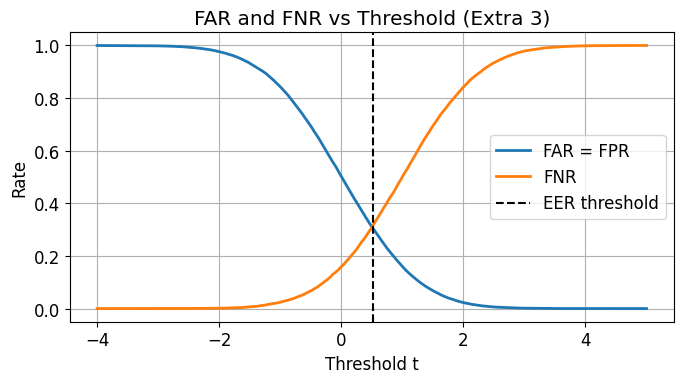

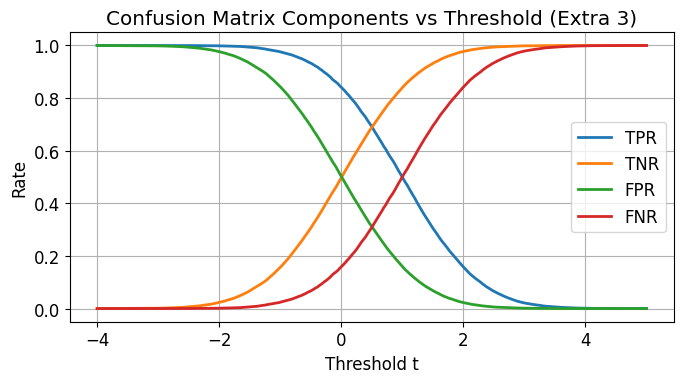

In [15]:
plt.figure(figsize=(7, 4))
# Plot how FPR (FAR) and FNR vary with the threshold
plt.plot(ts, FPR, label="FAR = FPR", linewidth=2)
plt.plot(ts, FNR, label="FNR", linewidth=2)
plt.axvline(eer_threshold, color="k", linestyle="--", label="EER threshold")
plt.xlabel("Threshold t")
plt.ylabel("Rate")
plt.title("FAR and FNR vs Threshold (Extra 3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Now I recompute the normalized confusion components explicitly for each threshold
TP_counts = []
FP_counts = []
TN_counts = []
FN_counts = []
for t in ts:
    preds = (samples > t).astype(int)
    TP = np.sum((preds == 1) & (labels == 1))
    FP = np.sum((preds == 1) & (labels == 0))
    TN = np.sum((preds == 0) & (labels == 0))
    FN = np.sum((preds == 0) & (labels == 1))
    # Normalize by class counts so these are all in [0, 1]
    TP_counts.append(TP / n2)
    FP_counts.append(FP / n1)
    TN_counts.append(TN / n1)
    FN_counts.append(FN / n2)
TP_counts = np.array(TP_counts)
FP_counts = np.array(FP_counts)
TN_counts = np.array(TN_counts)
FN_counts = np.array(FN_counts)
plt.figure(figsize=(7, 4))
# Plot all four normalized confusion components
plt.plot(ts, TP_counts, label="TPR", linewidth=2)
plt.plot(ts, TN_counts, label="TNR", linewidth=2)
plt.plot(ts, FP_counts, label="FPR", linewidth=2)
plt.plot(ts, FN_counts, label="FNR", linewidth=2)
plt.xlabel("Threshold t")
plt.ylabel("Rate")
plt.title("Confusion Matrix Components vs Threshold (Extra 3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra 4 – Bayes risk as a function of the threshold

Using the confusion components from the previous cell, I compute two types of Bayes risk for each threshold: one with equal misclassification costs (just the total error probability) and one that uses the asymmetric cost matrix from the problem statement. I also mark the analytical MAP and minimum-risk thresholds on this plot.


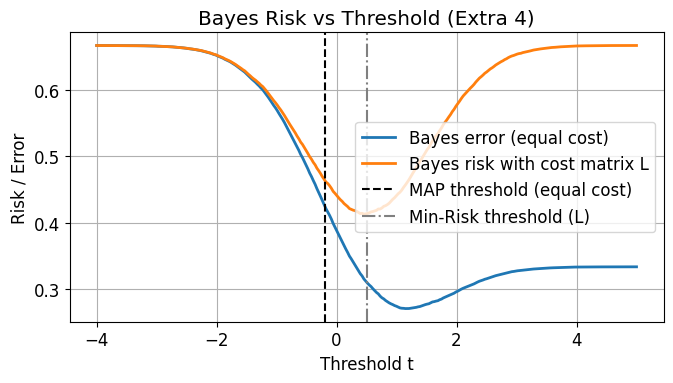

In [16]:
Risk_equal = []  # risk when both error types have cost 1
Risk_L = []      # risk when I use the asymmetric cost matrix
for i in range(len(ts)):
    # These are shorthand for the conditional probabilities at threshold ts[i]
    P_TP = TP_counts[i]
    P_FN = FN_counts[i]
    P_FP = FP_counts[i]
    P_TN = TN_counts[i]
    # Equal-cost Bayes error: just the total probability of making a wrong decision
    risk_eq = p1 * P_FP + p2 * P_FN
    Risk_equal.append(risk_eq)
    # Bayes risk under the given cost matrix:
    # - if I decide C2 when C1 is true, I pay L01
    # - if I decide C1 when C2 is true, I pay L10
    risk_L = p1 * P_FP * L01 + p2 * P_FN * L10
    Risk_L.append(risk_L)
Risk_equal = np.array(Risk_equal)
Risk_L = np.array(Risk_L)
plt.figure(figsize=(7, 4))
plt.plot(ts, Risk_equal, label="Bayes error (equal cost)", linewidth=2)
plt.plot(ts, Risk_L, label="Bayes risk with cost matrix L", linewidth=2)
# Show where the analytical thresholds from Extra 1 land on this curve
plt.axvline(th_map, color="k", linestyle="--", label="MAP threshold (equal cost)")
plt.axvline(th_min_risk, color="gray", linestyle="-.", label="Min-Risk threshold (L)")
plt.xlabel("Threshold t")
plt.ylabel("Risk / Error")
plt.title("Bayes Risk vs Threshold (Extra 4)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra 5 – How error changes with the class prior

I vary the prior probability of class C1 from 0.05 to 0.95. For each value I compute the optimal MAP threshold (analytically) and also keep a fixed mid-point threshold. Then I calculate the corresponding total error probabilities and compare them.

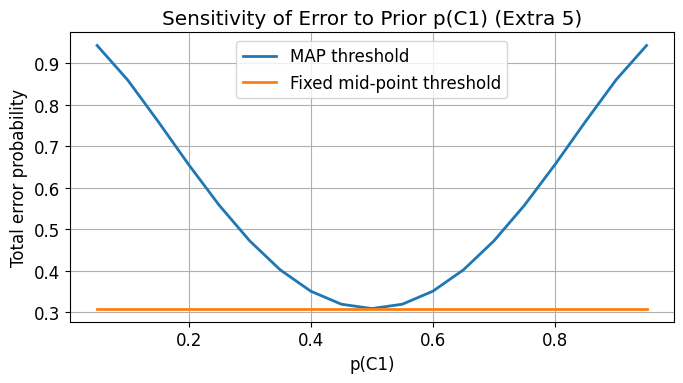

In [17]:
# Phi(z) = 0.5 * (1 + erf(z / sqrt(2)))
priors1 = np.linspace(0.05, 0.95, 19)
errors_map = []
errors_mid = []
for p1_tmp in priors1:
    p2_tmp = 1.0 - p1_tmp
    # Analytical MAP threshold for this pair of priors
    th_map_tmp = 0.5 * (mu1 + mu2) + (sigma1 ** 2 / (mu2 - mu1)) * log(p2_tmp / p1_tmp)
    # Fixed mid-point threshold (independent of the priors)
    th_mid_tmp = th_mid
    # Error for the MAP threshold (equal misclassification cost)
    z1_map = (th_map_tmp - mu1) / sigma1
    z2_map = (th_map_tmp - mu2) / sigma2
    P_FP_map = 1.0 - 0.5 * (1.0 + erf(z1_map / sqrt(2.0)))  # P(decide C2 | C1)
    P_FN_map = 0.5 * (1.0 + erf(z2_map / sqrt(2.0)))        # P(decide C1 | C2)
    err_map = p1_tmp * P_FP_map + p2_tmp * P_FN_map
    # Error for the fixed mid-point threshold
    z1_mid = (th_mid_tmp - mu1) / sigma1
    z2_mid = (th_mid_tmp - mu2) / sigma2
    P_FP_mid = 1.0 - 0.5 * (1.0 + erf(z1_mid / sqrt(2.0)))
    P_FN_mid = 0.5 * (1.0 + erf(z2_mid / sqrt(2.0)))
    err_mid = p1_tmp * P_FP_mid + p2_tmp * P_FN_mid
    errors_map.append(err_map)
    errors_mid.append(err_mid)
errors_map = np.array(errors_map)
errors_mid = np.array(errors_mid)
plt.figure(figsize=(7, 4))
plt.plot(priors1, errors_map, label="MAP threshold", linewidth=2)
plt.plot(priors1, errors_mid, label="Fixed mid-point threshold", linewidth=2)
plt.xlabel("p(C1)")
plt.ylabel("Total error probability")
plt.title("Sensitivity of Error to Prior p(C1) (Extra 5)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extra 6 – ROC comparison for equal vs unequal variances

Finally, I change the variance of the second class to make the Gaussians have unequal spreads. I generate a new Monte Carlo dataset and compute a new ROC curve under this setting.

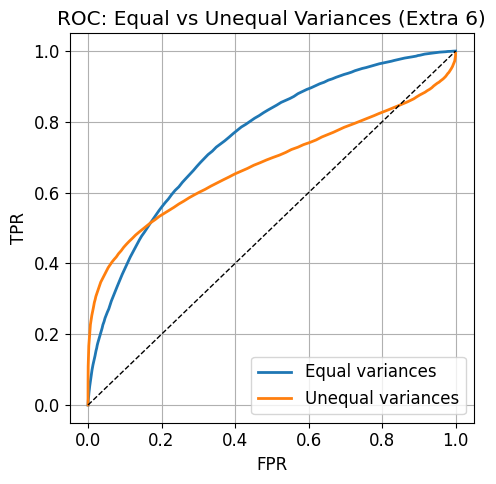

In [18]:
# I keep the same means and priors, but make sigma2 larger
mu1_2, mu2_2 = mu1, mu2
sigma1_2, sigma2_2 = sigma1, 2.0  # for example, class 2 is more spread out
p1_2, p2_2 = p1, p2
N2 = 50000
labels2 = np.random.choice([0, 1], size=N2, p=[p1_2, p2_2])
samples2 = np.zeros(N2)
# Draw samples for each class with the new variances
samples2[labels2 == 0] = np.random.normal(mu1_2, sigma1_2, size=(labels2 == 0).sum())
samples2[labels2 == 1] = np.random.normal(mu2_2, sigma2_2, size=(labels2 == 1).sum())
ts2 = np.linspace(mu1_2 - 4 * sigma1_2, mu2_2 + 4 * sigma2_2, 300)
TPR2 = []
FPR2 = []
n1_2 = (labels2 == 0).sum()
n2_2 = (labels2 == 1).sum()
for t in ts2:
    preds2 = (samples2 > t).astype(int)
    TP2 = np.sum((preds2 == 1) & (labels2 == 1))
    FP2 = np.sum((preds2 == 1) & (labels2 == 0))
    TPR2.append(TP2 / n2_2)
    FPR2.append(FP2 / n1_2)
TPR2 = np.array(TPR2)
FPR2 = np.array(FPR2)
plt.figure(figsize=(5, 5))
# ROC from the equal-variance case (Extra 2)
plt.plot(FPR, TPR, label="Equal variances", linewidth=2)
# ROC from the unequal-variance case
plt.plot(FPR2, TPR2, label="Unequal variances", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC: Equal vs Unequal Variances (Extra 6)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()